# Notebook 02 – Data Science and Machine Learning: fair tests for a CO₂ surrogate

How should a *surrogate*, a fast stand-in for the simulator, be tested so that a good score means good predictions for new geology and for the years after injection stops (*shut-in*)?

The data come from an *ensemble*, one simulation per *realisation* (sampled geology). Rows of one realisation share their geology, and rows after shut-in follow different physics, so I split by realisation, compare methods at the same tuning budget, and change shut-in time, rate schedule or boundary type one at a time. On toy data, random row splits flatter a model, one extreme case can drive a claimed difference, and an alarm threshold must be checked on new cases. The same design gives the geological spread `u_geo`, the yardstick for the other errors.

This notebook covers WP2 of my research proposal (draft v0.6.3). The simulated ensembles are proposed future work.

**Labels used in this notebook**

- **My work:** my own earlier work in Data Science and Machine Learning (completed exercises, analysis and explanations), summarised in §1.
- **Implemented example:** new code written for this notebook and run here on toy data, in under a minute.
- **Proposed adaptation:** what I plan to do in the PhD; not done yet.
- **Evaluated result:** a tested research result. There are none yet.

## 1. My work in Data Science and Machine Learning

*Label: My work (my own completed exercises).*

In the exercises I completed:

- preprocessing pipelines fitted on the training data only, to avoid **leakage** (information from the test data reaching the model);
- feature selection, by correlation screening and permutation importance (how much the score drops when one input is shuffled);
- threshold adjustment to reach a target precision of 90 %, with precision–recall and ROC curves;
- ensembles, which combine many models: bagging, random forests, boosting, voting and stacking;
- hyperparameter tuning by grid search and by random search with a fixed number of trials;
- learning curves;
- hold-outs that test on unseen parts of the data: a contiguous depth window, and one part of a survey area.

The datasets for these exercises were supplied with the course material, which acknowledges that most of its data were put together with Prof. Cedric John. My original exercise notebooks and their datasets are not reproduced in this repository.

## 2. From my work to the CO₂ problem

*Label: proposed adaptation.*

Each method from my work, what it becomes in WP2, and what has to change:

| Method from my work | Use in WP2 | What has to change |
|---|---|---|
| Split first; pipelines fitted on training data | Split by realisation; every scaler and transform fitted on training realisations only | The unit is a whole simulated history, not a row |
| Depth-window and spatial hold-outs | Held-out TEST geologies, simulated under baseline conditions and again with one factor changed: shut-in time, rate schedule or boundary type | The shift factors come from the physics; each shifted case changes one factor and is compared with the baseline case of the same geology |
| Tuning budgets | Every baseline and the surrogate get the same number of tuning trials, and the number is reported | Deep models cost more per trial, so the budget is also reported in GPU hours |
| Learning curves | Error against the number of simulated realisations | Sets the ensemble size before hundreds of simulations are run |
| Ensembles | Tree-ensemble baselines; deep ensembles for uncertainty (Notebook 03) | Out-of-fold predictions grouped by realisation |
| Thresholds for a target precision; precision–recall | An alarm for a wrong boundary assumption (Case C) (§8) | The threshold is set on calibration cases and checked on separate test cases; precision is estimated from few cases, so it needs its own interval |
| Feature selection | A first screen of which monitoring measurements carry information, before the formal identifiability study (WP4, Notebook 04) | Measurements are correlated in time, so permutation must be done in blocks |

## 3. A toy ensemble

*Label: implemented example (toy data made in this notebook, not simulation output).*

To show the test-design problems without running a simulator, I make a small ensemble with the same structure as the real one: 60 realisations, 25 yearly values each, and shut-in after year 14.

- Each realisation has a hidden geology value `theta`, like a shift in log-permeability.
- A well log measures it with noise (`log_measure`). Part of the geology (`unseen`) is not measured at all.
- The "plume area" grows during injection and then more slowly after shut-in.

Note: the numbers below come from this toy. Only the mechanisms carry over to real simulations, not the sizes of the effects.

In [1]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Building the toy ensemble: 60 realisations, years 0-24, shut-in after year 14
rng = np.random.default_rng(42)
n_real, years, shut_in = 60, np.arange(0, 25), 14

rows = []
for real in range(n_real):
    theta = rng.normal()                        # hidden geology
    log_measure = theta + 0.3 * rng.normal()    # what a well log tells us about it
    unseen = rng.normal()                       # geology that no measurement sees
    a = np.exp(0.4 * theta) * (1 + 0.25 * unseen)
    for t in years:
        if t <= shut_in:
            area = a * t**0.8                                         # growth during injection
        else:
            area = a * shut_in**0.8 + 0.6 * a * (t - shut_in)**0.5    # slower growth after shut-in
        rows.append((real, t, log_measure, area + 0.05 * rng.normal()))

df = pd.DataFrame(rows, columns=['realisation', 'year', 'log_measure', 'plume_area'])
print(f'the shape of the ensemble table is {df.shape}')
df.head()

the shape of the ensemble table is (1500, 4)


,realisation,year,log_measure,plume_area
0,0,0,-0.007278,0.047028
1,0,1,-0.007278,1.244007
2,0,2,-0.007278,2.270680
3,0,3,-0.007278,3.237167
4,0,4,-0.007278,4.051033


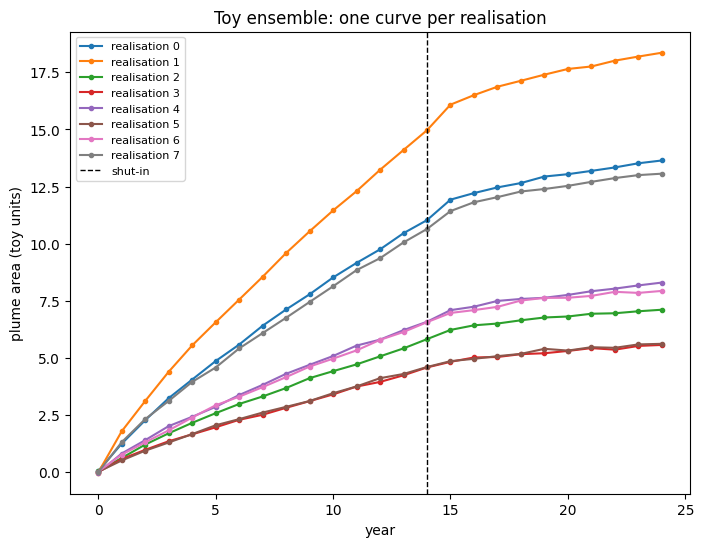

In [3]:
# Plot a few realisations
plt.figure(figsize=(8, 6))
for real in range(8):
    d = df[df.realisation == real]
    plt.plot(d.year, d.plume_area, marker='.', label=f'realisation {real}')
plt.axvline(shut_in, color='k', ls='--', lw=1, label='shut-in')
plt.xlabel('year')
plt.ylabel('plume area (toy units)')
plt.title('Toy ensemble: one curve per realisation')
plt.legend(fontsize=8);

#### How to read the plot above:

- Each curve is one realisation. The hidden geology scales the whole curve, so by year 24 these eight curves range from under 6 to over 18 toy units.
- Growth slows after shut-in (dashed line). A model trained only on years before shut-in has never seen this slower regime.

So a fair test must keep each realisation whole and must include years after shut-in; §4 shows what happens otherwise.

## 4. Four ways to split the same data

*Label: implemented example.*

How much does the way the data are split change the measured error? The same model is trained and tested four times, and only the split changes. The model is *extra trees*: 250 randomised decision trees whose predictions are averaged. The error is the root-mean-square error (RMSE) on the test rows:

- **(a)** random rows, all years;
- **(b)** by realisation: test realisations are never seen in training;
- **(c)** by realisation, using years up to 12 only;
- **(d)** by realisation, training on years up to 12 and testing on years 13–24, so the test crosses shut-in.

In [4]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_squared_error

X = df[['year', 'log_measure']]
y = df['plume_area']
groups = df['realisation']

def fit_rmse(train_idx, test_idx):
    # Fit the same model on the training rows and return the RMSE on the test rows
    model = ExtraTreesRegressor(n_estimators=250, random_state=42).fit(X.loc[train_idx], y.loc[train_idx])
    return mean_squared_error(y.loc[test_idx], model.predict(X.loc[test_idx]))**0.5

In [5]:
# (a) random rows, all years
train_idx, test_idx = train_test_split(df.index, test_size=0.3, random_state=42)
rmse_a = fit_rmse(train_idx, test_idx)

# (b) by realisation, all years
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_pos, test_pos = next(gss.split(X, y, groups))
train_g, test_g = df.index[train_pos], df.index[test_pos]
rmse_b = fit_rmse(train_g, test_g)

# (c) by realisation, years up to 12 only
early = df.year <= 12
rmse_c = fit_rmse(train_g[early.loc[train_g].values], test_g[early.loc[test_g].values])

# (d) by realisation, train on years up to 12, test on years 13-24
late = df.year >= 13
rmse_d = fit_rmse(train_g[early.loc[train_g].values], test_g[late.loc[test_g].values])

print(f'(a) random rows, all years:             RMSE {rmse_a:.2f}')
print(f'(b) by realisation, all years:          RMSE {rmse_b:.2f}  ({rmse_b / rmse_a:.1f} times (a))')
print(f'(c) by realisation, years up to 12:     RMSE {rmse_c:.2f}')
print(f'(d) train to year 12, test years 13-24: RMSE {rmse_d:.2f}  ({rmse_d / rmse_c:.1f} times (c))')

(a) random rows, all years:             RMSE 1.54
(b) by realisation, all years:          RMSE 3.43  (2.2 times (a))
(c) by realisation, years up to 12:     RMSE 2.16
(d) train to year 12, test years 13-24: RMSE 5.33  (2.5 times (c))


#### How to read this result:

- Random rows (a) give the lowest error. Splitting by realisation (b) more than doubles it, because with random rows the model has already seen other years of the same realisation and partly remembers its geology.
- Testing across shut-in (d) is about two and a half times worse than testing on the same years (c): the model has to extrapolate into a different regime.

Only (b) and (d) measure what the proposal needs. In WP2 every split is by realisation, and the time window and the regime are changed on purpose, one at a time (next section).

## 5. A paired factorial shift design

*Label: implemented example (the design table and its checks). No simulations are run.*

How much worse does a surrogate get when conditions change (a different shut-in time, rate schedule or boundary type), separately from how hard each geology is? A paired design answers this: the same held-out geology is simulated under the baseline conditions and again with one factor changed, and the errors of the two cases are compared on that geology.

In the PhD every row of the design is one **simulation case**: one geology run under one set of operating conditions. The design therefore uses two identifiers:

- `geology_id` names one sampled geology (a realisation);
- `case_id` names one simulation of that geology under one scenario.

Each geology belongs to exactly one group: TRAIN (to fit models), SELECT (to choose settings), CALIB (to calibrate uncertainty bands), TEST (to score) or AUDIT (a final check). Every geology is simulated once under the **baseline** conditions: a closed or semi-closed boundary, shut-in at year 14 and a constant rate.

For the shift tests, 20 of the 30 TEST geologies are simulated again: three times with one factor changed (**SHIFT**: shut-in time, rate schedule or boundary type), and once with all three changed (**COMPOUND**). A shift effect is the error of the shifted case minus the error of its baseline case, matched by `geology_id`, so the difficulty that belongs to the geology itself cancels out, as in the paired comparison of §7. **AUDIT** geologies are generated last, kept unseen, and scored once at the end.

The numbers of geologies and cases are placeholders. The learning curve (§6) and the computing budget (proposal §10) will set them.

In [6]:
def build_design(seed=42, n_paired=20):
    # One row per simulation case: geology_id names the geology, case_id the simulation of it
    rng = np.random.default_rng(seed)
    groups = [('TRAIN', 120), ('SELECT', 20), ('CALIB', 30), ('TEST', 30), ('AUDIT', 30)]
    shifts = {'SHIFT: shut-in time': {'shut_in_year': 10},        # each SHIFT changes one factor
              'SHIFT: rate schedule': {'schedule': 'stepped'},
              'SHIFT: boundary type': {'boundary': 'open'}}
    compound = {'shut_in_year': 10, 'schedule': 'stepped', 'boundary': 'open'}
    rows, g = [], 0
    for group, n in groups:
        for i in range(n):
            geology_id = f'G{g:03d}'
            base = {'boundary': rng.choice(['closed', 'semi-closed']), 'shut_in_year': 14, 'schedule': 'constant'}
            rows.append({'geology_id': geology_id, 'group': group, 'scenario': 'baseline', **base})
            if group == 'TEST' and i < n_paired:                   # the paired TEST geologies
                for scenario, change in shifts.items():
                    rows.append({'geology_id': geology_id, 'group': group, 'scenario': scenario, **base, **change})
                rows.append({'geology_id': geology_id, 'group': group, 'scenario': 'COMPOUND', **base, **compound})
            g += 1
    design = pd.DataFrame(rows)
    design.insert(0, 'case_id', [f'C{k:03d}' for k in range(len(design))])
    return design

design = build_design()
print(f'{design.geology_id.nunique()} geologies and {design.case_id.nunique()} simulation cases')
design.groupby(['group', 'scenario'], sort=False).agg(geologies=('geology_id', 'nunique'),
                                                      cases=('case_id', 'size'),
                                                      boundary=('boundary', lambda s: '/'.join(sorted(set(s)))),
                                                      shut_in_year=('shut_in_year', 'first'),
                                                      schedule=('schedule', 'first'))

230 geologies and 310 simulation cases


geologies  cases            boundary  \
group  scenario                                                     
TRAIN  baseline                    120    120  closed/semi-closed   
SELECT baseline                     20     20  closed/semi-closed   
CALIB  baseline                     30     30  closed/semi-closed   
TEST   baseline                     30     30  closed/semi-closed   
       SHIFT: shut-in time          20     20  closed/semi-closed   
       SHIFT: rate schedule         20     20  closed/semi-closed   
       SHIFT: boundary type         20     20                open   
       COMPOUND                     20     20                open   
AUDIT  baseline                     30     30  closed/semi-closed   

                             shut_in_year  schedule  
group  scenario                                      
TRAIN  baseline                        14  constant  
SELECT baseline                        14  constant  
CALIB  baseline                        14  constant  
TEST   baseline                        14  constant  
       SHIFT: shut-in time             10  constant  
       SHIFT: rate schedule            14   stepped  
       SHIFT: boundary type            14  constant  
       COMPOUND                        10   stepped  
AUDIT  baseline                        14  constant

In [7]:
FACTORS = ['boundary', 'shut_in_year', 'schedule']

def match_pairs(design):
    # Each shifted case with the baseline case of the same geology, matched by geology_id (not by row position)
    base = design[design.scenario == 'baseline'].set_index('geology_id')
    shifted = design[design.scenario != 'baseline']
    return shifted.join(base[['case_id', 'group'] + FACTORS], on='geology_id', rsuffix='_base')

pairs = match_pairs(design)
pairs[['geology_id', 'scenario', 'case_id', 'case_id_base'] + [c for f in FACTORS for c in (f + '_base', f)]].head(5)

,geology_id,scenario,case_id,case_id_base,boundary_base,boundary,shut_in_year_base,shut_in_year,schedule_base,schedule
171,G170,SHIFT: shut-in time,C171,C170,closed,closed,14,10,constant,constant
172,G170,SHIFT: rate schedule,C172,C170,closed,closed,14,14,constant,stepped
173,G170,SHIFT: boundary type,C173,C170,closed,open,14,14,constant,constant
174,G170,COMPOUND,C174,C170,closed,open,14,10,constant,stepped
176,G171,SHIFT: shut-in time,C176,C175,closed,closed,14,10,constant,constant


In [8]:
# Automated checks on the design
declared = {'SHIFT: shut-in time': 'shut_in_year', 'SHIFT: rate schedule': 'schedule', 'SHIFT: boundary type': 'boundary'}
main_groups = ['TRAIN', 'SELECT', 'CALIB', 'TEST', 'AUDIT']

# 1. every simulation case has its own identifier
assert design.case_id.is_unique
# 2. no geology leakage: each geology sits in exactly one group
assert (design.groupby('geology_id').group.nunique() == 1).all()
assert set(design.group) == set(main_groups)
# 3. every shifted case has one baseline case of the same geology, inside the same group
assert (design[design.scenario == 'baseline'].groupby('geology_id').size() == 1).all()
assert pairs.case_id_base.notna().all() and (pairs.group == pairs.group_base).all()
# 4. inside each single-factor pair, only the declared factor changes
for scenario, factor in declared.items():
    p = pairs[pairs.scenario == scenario]
    for f in FACTORS:
        differs = p[f] != p[f + '_base']
        assert differs.all() if f == factor else not differs.any(), (scenario, f)
# 5. compound cases change more than one factor and carry their own label
c = pairs[pairs.scenario == 'COMPOUND']
assert (sum((c[f] != c[f + '_base']).astype(int) for f in FACTORS) >= 2).all()
assert set(pairs.scenario) == set(declared) | {'COMPOUND'}
# 6. the audit group stays separate: baseline cases only, on geologies used nowhere else
audit = design[design.group == 'AUDIT']
assert (audit.scenario == 'baseline').all()
assert not set(audit.geology_id) & set(design.loc[design.group != 'AUDIT', 'geology_id'])
# 7. the pairs do not depend on the order of the rows
shuffled = match_pairs(design.sample(frac=1, random_state=42))
assert set(zip(shuffled.case_id, shuffled.case_id_base)) == set(zip(pairs.case_id, pairs.case_id_base))

print('all design checks passed')
print(f'{design.geology_id.nunique()} geologies and {len(design)} simulation cases')
print(f'{pairs.geology_id.nunique()} TEST geologies carry {len(pairs)} shifted cases '
      f'({(pairs.scenario != "COMPOUND").sum()} single-factor, {(pairs.scenario == "COMPOUND").sum()} compound), '
      f'each matched to the baseline case of its geology')

all design checks passed
230 geologies and 310 simulation cases
20 TEST geologies carry 80 shifted cases (60 single-factor, 20 compound), each matched to the baseline case of its geology


#### How to read this result:

- The design has 230 geologies and 310 simulation cases. Most geologies are simulated once. The 20 paired TEST geologies are simulated five times each (baseline, three single-factor shifts and the compound case), which gives the 80 shifted cases; the other 10 TEST geologies have a baseline case only.
- The table of pairs shows the matching: each shifted case (`case_id`) sits next to the baseline case of the same geology (`case_id_base`), and only the declared factor differs. For geology G170, for example, the shut-in shift changes the shut-in year from 14 to 10 and nothing else.
- All seven checks pass. The last one shows that shuffling the rows leaves every pair unchanged, because pairs are found by `geology_id`, not by position.
- The COMPOUND cases change all three factors. They are reported on their own, as interactions, and never counted as a single-factor effect.
- Pairing needs no extra geologies: the shifted cases reuse held-out TEST geologies, and no TEST or AUDIT geology appears in training.

Each shift effect is therefore the extra error caused by the change of conditions alone, which shows whether a surrogate trained with one shut-in time, schedule or boundary can be used for another.

## 6. A learning curve by realisation

*Label: implemented example.*

How many simulated realisations are needed to train a model? A *learning curve* shows the test error against the size of the training set. This follows the learning-curve helper I wrote in my earlier work, changed so that the unit of training data is a realisation instead of a row. Because a small training set can be lucky or unlucky, each size is repeated 10 times with different realisations, and the test set is always 15 unseen realisations.

In [9]:
def calculate_learning_curve_by_realisation(model, sizes, n_repeats=10, n_test=15):
    # For each training size: pick realisations at random, fit, and score on unseen realisations
    mean_rmse, std_rmse = [], []    # creating empty lists that will be filled for each size
    for m in sizes:
        scores = []
        for rep in range(n_repeats):
            ids = np.random.default_rng(100 + rep).permutation(n_real)
            test = df.realisation.isin(ids[:n_test])
            train = df.realisation.isin(ids[n_test:n_test + m])
            model.fit(X[train], y[train])
            scores.append(mean_squared_error(y[test], model.predict(X[test]))**0.5)
        mean_rmse.append(np.mean(scores))
        std_rmse.append(np.std(scores))
    return mean_rmse, std_rmse

sizes = [5, 10, 20, 40]
mean_rmse, std_rmse = calculate_learning_curve_by_realisation(ExtraTreesRegressor(n_estimators=250, random_state=42), sizes)
for m, mu_, sd in zip(sizes, mean_rmse, std_rmse):
    print(f'{m:3d} training realisations: RMSE {mu_:.2f} +/- {sd:.2f}')

  5 training realisations: RMSE 3.85 +/- 1.33
 10 training realisations: RMSE 3.51 +/- 1.00
 20 training realisations: RMSE 3.27 +/- 0.82
 40 training realisations: RMSE 3.36 +/- 0.55


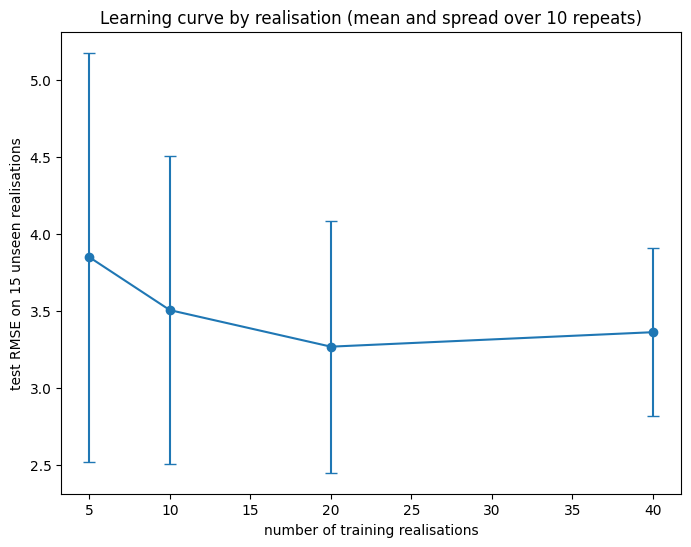

In [10]:
# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.errorbar(sizes, mean_rmse, yerr=std_rmse, marker='o', capsize=4)
plt.xlabel('number of training realisations')
plt.ylabel('test RMSE on 15 unseen realisations')
plt.title('Learning curve by realisation (mean and spread over 10 repeats)');

#### How to read the curve above:

- The error falls from 5 to 20 realisations and then stops improving; the spread between repeats keeps shrinking.
- In this toy the floor comes from what the inputs do not measure: the unmeasured part of the geology and the noise in the log. More realisations cannot remove it; better inputs could.

In WP2 the same curve, from the first batch of simulations, shows whether more runs are worth their cost, and how much of the error is a floor.

## 7. The same tuning budget for every method, and a paired comparison

*Label: implemented example.*

Is one method really better than another, or is the difference within the noise of a small test set? Three baselines get the same tuning budget: 8 random trials each, with 5-fold cross-validation grouped by realisation on the training realisations from split (b). *Cross-validation* scores each trial on parts of the training data held back in turn; grouping keeps each realisation within one part. Each tuned model is then scored on the held-out test realisations.

The comparison follows rule R1 of the proposal (§7): compute the error of both methods on each test realisation, take the differences, and claim a difference only if a 95 % bootstrap interval of the mean difference excludes zero. The *bootstrap* resamples the test realisations many times to see how much the mean difference could vary. Pairing matters because some realisations are hard for every method.

In [11]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import loguniform, randint

X_train, y_train, g_train = X.loc[train_g], y.loc[train_g], groups.loc[train_g]
X_test, y_test, g_test = X.loc[test_g], y.loc[test_g], groups.loc[test_g]

candidates = {
    'ridge': (Pipeline([('scale', StandardScaler()), ('model', Ridge())]),
              {'model__alpha': loguniform(1e-3, 1e3)}),
    'random forest': (RandomForestRegressor(random_state=42),
                      {'n_estimators': randint(50, 300), 'max_depth': randint(2, 12)}),
    'extra trees': (ExtraTreesRegressor(random_state=42),
                    {'n_estimators': randint(50, 300), 'max_depth': randint(2, 12)}),
}

budget = 8    # the same number of tuning trials for every method
per_real = {}
for name, (estimator, space) in candidates.items():
    search = RandomizedSearchCV(estimator, space, n_iter=budget, cv=GroupKFold(n_splits=5),
                                scoring='neg_root_mean_squared_error', random_state=42)
    search.fit(X_train, y_train, groups=g_train)
    err = (search.predict(X_test) - y_test)**2
    per_real[name] = err.groupby(g_test).mean()**0.5          # RMSE of each test realisation
    print(f'{name:14s} tuned CV RMSE {-search.best_score_:.2f}, test RMSE {mean_squared_error(y_test, search.predict(X_test))**0.5:.2f}')

ridge          tuned CV RMSE 2.96, test RMSE 4.31


random forest  tuned CV RMSE 3.03, test RMSE 2.77


extra trees    tuned CV RMSE 2.53, test RMSE 2.86


In [12]:
# Rule R1: paired bootstrap over test realisations
def paired_bootstrap(a, b, n_boot=10000, seed=42):
    # 95 % interval for the mean of (a - b) over test realisations
    d = (a - b).values
    rng = np.random.default_rng(seed)
    means = [rng.choice(d, size=len(d), replace=True).mean() for _ in range(n_boot)]
    return d.mean(), np.percentile(means, [2.5, 97.5])

print(f'{len(per_real["ridge"])} test realisations')
for a, b_ in [('random forest', 'extra trees'), ('ridge', 'extra trees'), ('ridge', 'random forest')]:
    mean_d, (lo, hi) = paired_bootstrap(per_real[a], per_real[b_])
    verdict = 'difference claimed' if (lo > 0 or hi < 0) else 'no difference claimed'
    print(f'{a} minus {b_}: mean {mean_d:+.2f}, 95 % interval [{lo:+.2f}, {hi:+.2f}] -> {verdict}')

18 test realisations
random forest minus extra trees: mean -0.18, 95 % interval [-0.47, +0.11] -> no difference claimed


ridge minus extra trees: mean +0.75, 95 % interval [+0.12, +1.76] -> difference claimed
ridge minus random forest: mean +0.93, 95 % interval [+0.20, +2.10] -> difference claimed


In [13]:
# Checking the comparison: are the same realisations hard for every method, and how much does one realisation matter?
errors = pd.DataFrame(per_real)
print('correlation of the per-realisation RMSE between methods:')
print(errors.corr().round(2))

d = errors['ridge'] - errors['extra trees']
worst = d.abs().idxmax()
print(f'\nridge is worse than extra trees on {(d > 0).sum()} of {len(d)} test realisations')
print(f'largest single difference: {d[worst]:+.2f}, on realisation {worst}, whose log measure is '
      f'{df.loc[df.realisation == worst, "log_measure"].iloc[0]:.2f} (highest in the ensemble: {df.log_measure.max():.2f})')
mean_d, (lo, hi) = paired_bootstrap(errors['ridge'].drop(worst), errors['extra trees'].drop(worst))
print(f'ridge minus extra trees without realisation {worst}: mean {mean_d:+.2f}, 95 % interval [{lo:+.2f}, {hi:+.2f}]')

correlation of the per-realisation RMSE between methods:
               ridge  random forest  extra trees
ridge           1.00           0.64         0.80
random forest   0.64           1.00         0.91
extra trees     0.80           0.91         1.00

ridge is worse than extra trees on 11 of 18 test realisations
largest single difference: +8.41, on realisation 52, whose log measure is 2.33 (highest in the ensemble: 2.33)


ridge minus extra trees without realisation 52: mean +0.30, 95 % interval [+0.06, +0.52]


#### How to read this result:

- With the same budget of 8 trials, the two tree ensembles reach similar test errors (2.77 and 2.86). Ridge, a linear model with a penalty on large coefficients, is worse (4.31): it cannot follow the slower growth after shut-in or the way the geology scales the whole curve.
- The cross-validation scores ranked the methods differently (extra trees 2.53, ridge 2.96, random forest 3.03). With 42 training and 18 test realisations one ranking can easily change, which is why rule R1 asks for an interval before a difference is claimed.
- Random forest minus extra trees: the interval (−0.47 to +0.11) contains zero, so no difference is claimed between the two tree ensembles. Ridge is worse than both, and both of its intervals exclude zero.
- The check cell shows why pairing helps. The errors of the three methods on the same realisation are strongly correlated (0.64 to 0.91): some realisations are hard for every method, and comparing each realisation with itself removes that shared difficulty.
- It also shows a warning. Most of ridge's disadvantage comes from one realisation, number 52, whose log measure (2.33) is the highest in the ensemble. Every method has to extrapolate there, and ridge's straight line is far off (8.41 worse than extra trees). Without it, ridge is still worse than extra trees, but the mean difference falls from +0.75 to +0.30, and ridge is worse on only 11 of the 18 realisations.

With 18 test realisations, one extreme case can set the size of a claim. In WP2 I would report how many realisations each method wins alongside the interval, and size the test sets with this in mind.

## 8. An alarm for a wrong boundary, with its threshold set on separate cases

*Label: implemented example (Theis solution with an image well; no reservoir simulation).*

Can pressure gauges warn that the boundary assumed in the model is wrong (Case C in the proposal)? A sealing fault near the injector keeps pressure high after shut-in, as the Snøhvit shut-in pressures showed (proposal §2.2). The alarm is a classifier with a threshold chosen for a target precision, as in my earlier threshold-adjustment exercise, with one change (below). *Precision* is the share of alarms that are real faults; *recall* is the share of real faults that raise an alarm.

I make gauge readings for 600 cases, about half with a sealing fault and half without. I use the Theis solution from Notebook 01 and represent the fault by an **image well**: a second injector mirrored across the fault, the standard well-testing way to model a no-flow boundary. Permeability, compressibility and the distance to the fault are uncertain, and the gauge has noise.

The two features are the log of the overpressure at shut-in, and the ratio of the overpressure two years after shut-in to that at shut-in.

The one change from my earlier exercise: there I chose the threshold for 90 % precision on the test split and checked it on the same split. Here the threshold is chosen on calibration cases and checked on test cases that played no part in choosing it:

1. Split the cases into training, calibration and test sets.
2. Train a logistic regression (a linear model that gives the probability of a fault) on the training cases.
3. On the calibration cases, choose the lowest threshold that gives a precision of at least 0.90 (so that nine alarms in ten are real faults).
4. Report precision and recall on the test cases.
5. Look at which faults are missed, and at the false alarms.

In [14]:
from scipy.special import exp1

yr = 365.25 * 24 * 3600
h, phi, mu, q, t_s, r = 50.0, 0.3, 5e-4, 0.045, 10 * yr, 1000.0   # same values as Notebook 01

rng = np.random.default_rng(42)
n = 600
k = 2e-13 * np.exp(0.3 * rng.normal(size=n))    # uncertain permeability
ct = rng.uniform(0.5e-9, 2e-9, size=n)          # uncertain total compressibility
fault = rng.integers(0, 2, size=n)              # 1 = sealing fault present
L_fault = rng.uniform(1500, 5000, size=n)       # distance from injector to the fault, m

def theis(dist, t, k, ct):
    # Theis overpressure at a distance dist from a well injecting since time 0
    D = k / (phi * mu * ct)
    return q * mu / (4 * np.pi * k * h) * exp1(dist**2 / (4 * D * t))

def gauge(t, k, ct, fault, L_fault):
    # Overpressure at the monitoring well: real well plus, if there is a fault, its image well
    image_dist = r + 2 * L_fault                  # fault on the far side of the injector
    dp = theis(r, t, k, ct) + fault * theis(image_dist, t, k, ct)
    if t > t_s:                                   # shut-in by superposition
        dp -= theis(r, t - t_s, k, ct) + fault * theis(image_dist, t - t_s, k, ct)
    return dp

p_shut = gauge(t_s, k, ct, fault, L_fault) + 0.02e6 * rng.normal(size=n)          # 0.02 MPa gauge noise
p_later = gauge(t_s + 2 * yr, k, ct, fault, L_fault) + 0.02e6 * rng.normal(size=n)
features = np.column_stack([np.log(p_shut), p_later / p_shut])
print(f'{fault.sum()} cases with a fault, {n - fault.sum()} without')

298 cases with a fault, 302 without


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, precision_recall_curve
from scipy.stats import beta

# Step 1: split the cases into training, calibration and test sets (case numbers are kept for Step 5)
cases = np.arange(n)
X_tr, X_rest, y_tr, y_rest, id_tr, id_rest = train_test_split(features, fault, cases, test_size=0.5, random_state=42, stratify=fault)
X_cal, X_te, y_cal, y_te, id_cal, id_te = train_test_split(X_rest, y_rest, id_rest, test_size=0.5, random_state=42, stratify=y_rest)

# Step 2: train the classifier on the training cases
clf = LogisticRegression().fit(X_tr, y_tr)

# Step 3: lowest threshold with precision of at least 0.90 on the calibration cases
precisions, recalls, thresholds = precision_recall_curve(y_cal, clf.predict_proba(X_cal)[:, 1])
threshold = thresholds[np.argmax(precisions[:-1] >= 0.90)]
print(f'threshold chosen on {len(y_cal)} calibration cases: {threshold:.3f}')

# Step 4: precision and recall on the test cases
alarm = clf.predict_proba(X_te)[:, 1] >= threshold
true_alarms, n_alarms = int((alarm & (y_te == 1)).sum()), int(alarm.sum())
lo, hi = beta.ppf(0.025, true_alarms, n_alarms - true_alarms + 1), beta.ppf(0.975, true_alarms + 1, n_alarms - true_alarms)
print(f'test cases: {len(y_te)}, alarms raised: {n_alarms}, of which real faults: {true_alarms}')
print(f'test precision {precision_score(y_te, alarm):.2f} (95 % interval {lo:.2f}-{hi:.2f}), recall {recall_score(y_te, alarm):.2f}')

threshold chosen on 150 calibration cases: 0.587
test cases: 150, alarms raised: 56, of which real faults: 47
test precision 0.84 (95 % interval 0.72-0.92), recall 0.64


In [16]:
# Step 5: which faults are missed? Recall on the test cases, for near and far faults
far = L_fault[id_te] >= 2500
for name, group in [('closer than 2.5 km', ~far), ('2.5-5 km away', far)]:
    faults_here = (y_te == 1) & group
    print(f'faults {name}: {faults_here.sum()} test cases, {alarm[faults_here].sum()} detected (recall {alarm[faults_here].mean():.2f})')

# What do the false alarms look like? Their permeability against all test cases without a fault
false_alarm = alarm & (y_te == 0)
print(f'mean permeability of the {false_alarm.sum()} false alarms: {k[id_te][false_alarm].mean():.1e} m2 '
      f'(all {(y_te == 0).sum()} test cases without a fault: {k[id_te][y_te == 0].mean():.1e} m2)')

faults closer than 2.5 km: 29 test cases, 26 detected (recall 0.90)
faults 2.5-5 km away: 45 test cases, 21 detected (recall 0.47)
mean permeability of the 9 false alarms: 1.3e-13 m2 (all 76 test cases without a fault: 2.1e-13 m2)


#### How to read this result:

- The threshold (0.587) was chosen where precision on the 150 calibration cases first reached 0.90. On the 150 test cases the alarm was raised 56 times and 47 were real faults: a precision of 0.84.
- 0.84 is below the target, but its 95 % interval (0.72–0.92; a Clopper–Pearson interval, exact for a proportion) still contains 0.90, so this test cannot show whether the target is met. A threshold chosen at the edge of a target usually loses some precision on new cases. This is why proportions estimated from few cases are reported with an interval, as coverage is in the proposal (§7).
- Recall is 0.64: about one fault in three is missed. Step 5 shows which. Faults closer than 2.5 km are found in 26 of 29 cases (recall 0.90), farther ones in 21 of 45 (0.47): a distant fault changes the gauge readings less.
- The 9 false alarms have a lower average permeability than the test cases without a fault (1.3e-13 against 2.1e-13 m²). Lower permeability also raises the overpressure at shut-in and increases the two-year ratio, as a fault does, so two gauge values cannot always tell them apart.

In the PhD this becomes a monitoring-design question for WP4: where to place gauges, how long to record after shut-in, and whether time-lapse seismic adds information. The value-of-information study compares these options (proposal §6 WP4, Case C).

## 9. How WP2 will be evaluated

*Label: proposed adaptation. Values in square brackets are set with the supervisor before any results exist.*

The examples of §§4–8 become rules for the real ensembles:

| What | How it is checked |
|---|---|
| Splits | Every geology sits in one group only; the automated checks of §5 run on the real design |
| Shift effects | For each SHIFT case, its error minus the error of the baseline case of the same TEST geology, matched by `geology_id`; a 95 % paired bootstrap interval over geologies (rule R1), before and after shut-in. COMPOUND cases are reported separately |
| Baselines | Analytic estimates (Notebook 01), ridge, tree ensembles and regression on principal field patterns, all at the same tuning budget |
| Ensemble size | Learning curves from the first [100] realisations; more runs only if the curve is still falling |
| Audit | The AUDIT geologies are scored once, after all choices are frozen |
| Alarm for a wrong boundary | Threshold set on calibration cases; precision and recall on test cases, with intervals |

The shift effects are measured against the production-grid reference, the simulation the surrogate learns from. A claim about accuracy against the refined numerical reference under a shift also needs refined cases of that shift (Notebook 01 §6); without them it stays provisional.

The outputs of WP2 are the geological spread `u_geo` of each decision quantity, the test sets, and the baseline scores (proposal §7).

## 10. Assumptions and what has to change

- The toy data only show mechanisms. In the PhD every row comes from a simulation, and the sizes of the effects will be different.
- A geology is treated as exchangeable with the others in its group. The shifted cases break this on purpose, one factor at a time, on held-out TEST geologies.
- Pairing assumes that a shifted case and its baseline differ only in the declared factor. The checks in §5 confirm this for the recorded factors; the simulation set-up must keep everything else the same, such as the grid, the geology realisation and the solver settings.
- Time series from one realisation are strongly correlated, so any cross-validation, permutation or bootstrap must work on whole realisations or blocks of time.
- The image-well alarm uses single-phase pressure and one straight fault. Real cases have two-phase flow near the well, several faults, and gauge drift; WP4 combines gauges with seismic for that reason.
- Set sizes and tolerances are placeholders until the learning curve and the computing budget are known.

## 11. Status

**Run here:** the implemented examples of §§3–8, on toy data and a textbook pressure solution; the design of §5 is a table, with no simulations. **Proposed for the PhD:** the WP2 ensembles, shift cases and baselines on real simulations (§9). **My work:** summarised in §1. **Research results:** none yet.

## References and further reading

- Clopper, C. J. & Pearson, E. S. (1934). The use of confidence or fiducial limits illustrated in the case of the binomial. *Biometrika* 26(4), 404–413.
- Pedregosa, F. et al. (2011). Scikit-learn: machine learning in Python. *Journal of Machine Learning Research* 12, 2825–2830.
- Theis, C. V. (1935). The relation between the lowering of the piezometric surface and the rate and duration of discharge of a well using ground-water storage. *Transactions, American Geophysical Union* 16(2), 519–524.